In [1]:
!pwd

/truejit/evaluation/smartjit


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
from pathlib import Path

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [3]:
from jetstream.gcc_loops.benchmark import gcc_loops

benchmark = gcc_loops

In [4]:
from Profiling import StaticCompiler

sc = StaticCompiler()

In [5]:
from Profiling import VirtualMachine

vm = VirtualMachine()

In [6]:
from Profiling import StaticAsyncPlanner

sap = StaticAsyncPlanner()

In [7]:
from mibench.suite import mibench
from spec.suite import spec
from coremark.benchmark import coremark
from ffmpeg.benchmark import ffmpeg
from sqlite.benchmark import sqlite
from jetstream.suite import jetstream
from polybench.suite import suite as polybench
from npb.suite import suite as npb
from wabench.suite import wabench

all_benchmarks = []
all_benchmarks.extend(jetstream.benchmarks)
all_benchmarks.extend([sqlite])
all_benchmarks.extend(mibench.benchmarks)
all_benchmarks.extend(spec.benchmarks)
all_benchmarks.extend(npb('S').benchmarks)
all_benchmarks.extend(wabench.benchmarks)
all_benchmarks.extend([coremark])
all_benchmarks.extend(polybench('standard').benchmarks)
all_benchmarks.extend([ffmpeg])

In [10]:
timelines_dir = Path('./out/timelines')
timelines_dir.mkdir(parents=True, exist_ok=True)


def find_first_surplus_point(waiting_times):  # [f, start, end]
    functions = []
    start_time = waiting_times[0][1]
    waiting_times = [(f, s - start_time, e - start_time) for f, s, e in waiting_times]
    surplus = 0
    current_time = 0
    for f, s, e in waiting_times:
        surplus += s - current_time
        if surplus > 0:
            break
        functions.append(f)
        surplus -= e - s
        current_time = e
        # print(f'{f:4} {s:>10} {e:>10} {surplus:>10}')
    return current_time, functions


def plot_timelines(benchmark, profiles):
    max_duration = 0  # (for x-axis)
    max_compilations = 0  # (for y-axis)
    for profile in profiles:
        max_duration = max(max_duration, profile.end - profile.start)
        max_compilations = max(max_compilations, len(profile.compilation_service.times))
    max_x, max_y = max_duration, max_compilations

    width = 10
    height = 1.2 * len(profiles)
    height = max(height, 1.5)
    fig, axs = plt.subplots(figsize=(width, height), dpi=320,
                            nrows=len(profiles), ncols=1,
                            sharex=True, sharey=True)
    if len(profiles) == 1:
        axs = [axs]

    for ax, profile in zip(axs, profiles):
        start = profile.start

        static_start = profile.virtual_machine.static_start
        static_start -= start
        ax.axvline(x=static_start, color='black', linestyle='dashed', linewidth=.5)

        static_end = profile.virtual_machine.static_end
        static_end -= start
        ax.axvline(x=static_end, color='red', linestyle='dashed', linewidth=.5)

        exec_start = profile.virtual_machine.start
        exec_start -= start
        ax.axvline(x=exec_start, color='purple', linestyle='dashed', linewidth=.5)

        exec_end = profile.virtual_machine.end
        exec_end -= start
        ax.axvline(x=exec_end, color='pink', linestyle='dashed', linewidth=.5)

        end = profile.end
        end -= start
        ax.axvline(x=end, color='green', linestyle='dashed', linewidth=.5)

        wasm = profile.wasm_service.times  # [app, start, end]
        wasm = [(c[1], c[2]) for c in wasm]  # [start, end]
        wasm = sorted(wasm, key=lambda x: x[0])  # sort by start
        wasm = [(c[0], c[1] - c[0]) for c in wasm]  # [start, duration]
        wasm = [(c[0] - start, c[1]) for c in wasm]  # subtract start
        for s, d in wasm:
            ax.plot([s, s + d], [0, 0], c='orange', linewidth=1)

        compilations = profile.compilation_service.times  # [app, fn, size, start, end]
        compilations = [(c[2], c[3]) for c in compilations]  # [start, end]
        compilations = sorted(compilations, key=lambda x: x[0])  # sort by start
        compilations = [(c[0], c[1] - c[0]) for c in compilations]  # [start, duration]
        compilations = [(c[0] - start, c[1]) for c in compilations]  # subtract start
        y_offset = .03 * max_compilations
        for y, (s, d) in enumerate(compilations):
            ax.plot([s, s + d], [y + y_offset, y + y_offset], c='blue', linewidth=1)

        latencies = profile.virtual_machine.times  # [f, start, end]
        latencies = [(c[1], c[2]) for c in latencies]  # [start, end]
        latencies = sorted(latencies, key=lambda x: x[0])  # sort by start
        latencies = [(c[0], c[1] - c[0]) for c in latencies]  # [start, duration]
        latencies = [(c[0] - start, c[1]) for c in latencies]  # subtract start
        for y, (s, d) in enumerate(latencies):
            ax.plot([s, s + d], [y, y], c='red', linewidth=1)

        # if len(profile.virtual_machine.times) > 0:
        #     surplus_point, _ = find_first_surplus_point(profile.virtual_machine.times)
        #     ax.axvline(x=surplus_point, color='black', linestyle='dashed', linewidth=.5)

        title = profile.title
        title = title.replace('%', r'\%').replace(' ', r'\ \ \ ')
        ax.set_title(title, loc='left', fontweight='normal', color='blue')

        exec_text = f'{profile.virtual_machine.exec / 1_000_000_000.0:>.1f} executing'
        compilation_text = f'{profile.compilation_service.total / 1_000_000_000.0:>.1f} compiling'
        waiting_text = f'{profile.virtual_machine.waiting / 1_000_000_000.0:>.1f} waiting'
        x = exec_end + (.005 * max_x)
        ax.text(x=x, y=.6 * max_y, s=exec_text, ha='left', va='bottom', color='green')
        ax.text(x=x, y=.3 * max_y, s=compilation_text, ha='left', va='bottom', color='blue')
        ax.text(x=x, y=.0 * max_y, s=waiting_text, ha='left', va='bottom', color='red')

        ax.grid(False)
        ax.margins(0)

    # x-axis
    ax.set_xlim(0, 1.2 * max_x)

    def format_func(value, _):  # show seconds
        sec = value / 1_000_000_000
        if sec == int(sec):
            return f'{int(sec)}'
        return f'{sec:.1f}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

    # y-axis
    ax.set_ylim(-0.05 * max_y, 1.01 * max_y)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Functions')

    plt.tight_layout()

    plt.savefig(timelines_dir / f'{benchmark.mode}.pdf', format='pdf', dpi=320, bbox_inches='tight', pad_inches=0.1)

    plt.show()

# plot_timelines(benchmark, profiles)
# plot_timelines(benchmark, [vm.run(benchmark, ['--sync=jit', '--async=static'])])

benchmark=gcc-loops
Binary directory: /truejit/binaries/jetstream/gcc_loops
[static-compiler][result] compilation=30.9 (seconds)      
scheme=['--sync=jit']
[virtual-machine][result] compilation=1.7 waiting=1.8 exec=5.2 end-to-end=7.0 (seconds)
scheme=['--sync=jit', '--async=static']
[virtual-machine][result] compilation=4.3 waiting=1.1 exec=5.7 end-to-end=6.8 (seconds)
scheme=['--static=max-surplus']
[virtual-machine][result] compilation=0.6 waiting=0.7 exec=4.9 end-to-end=5.5 verification=0.001 (seconds)


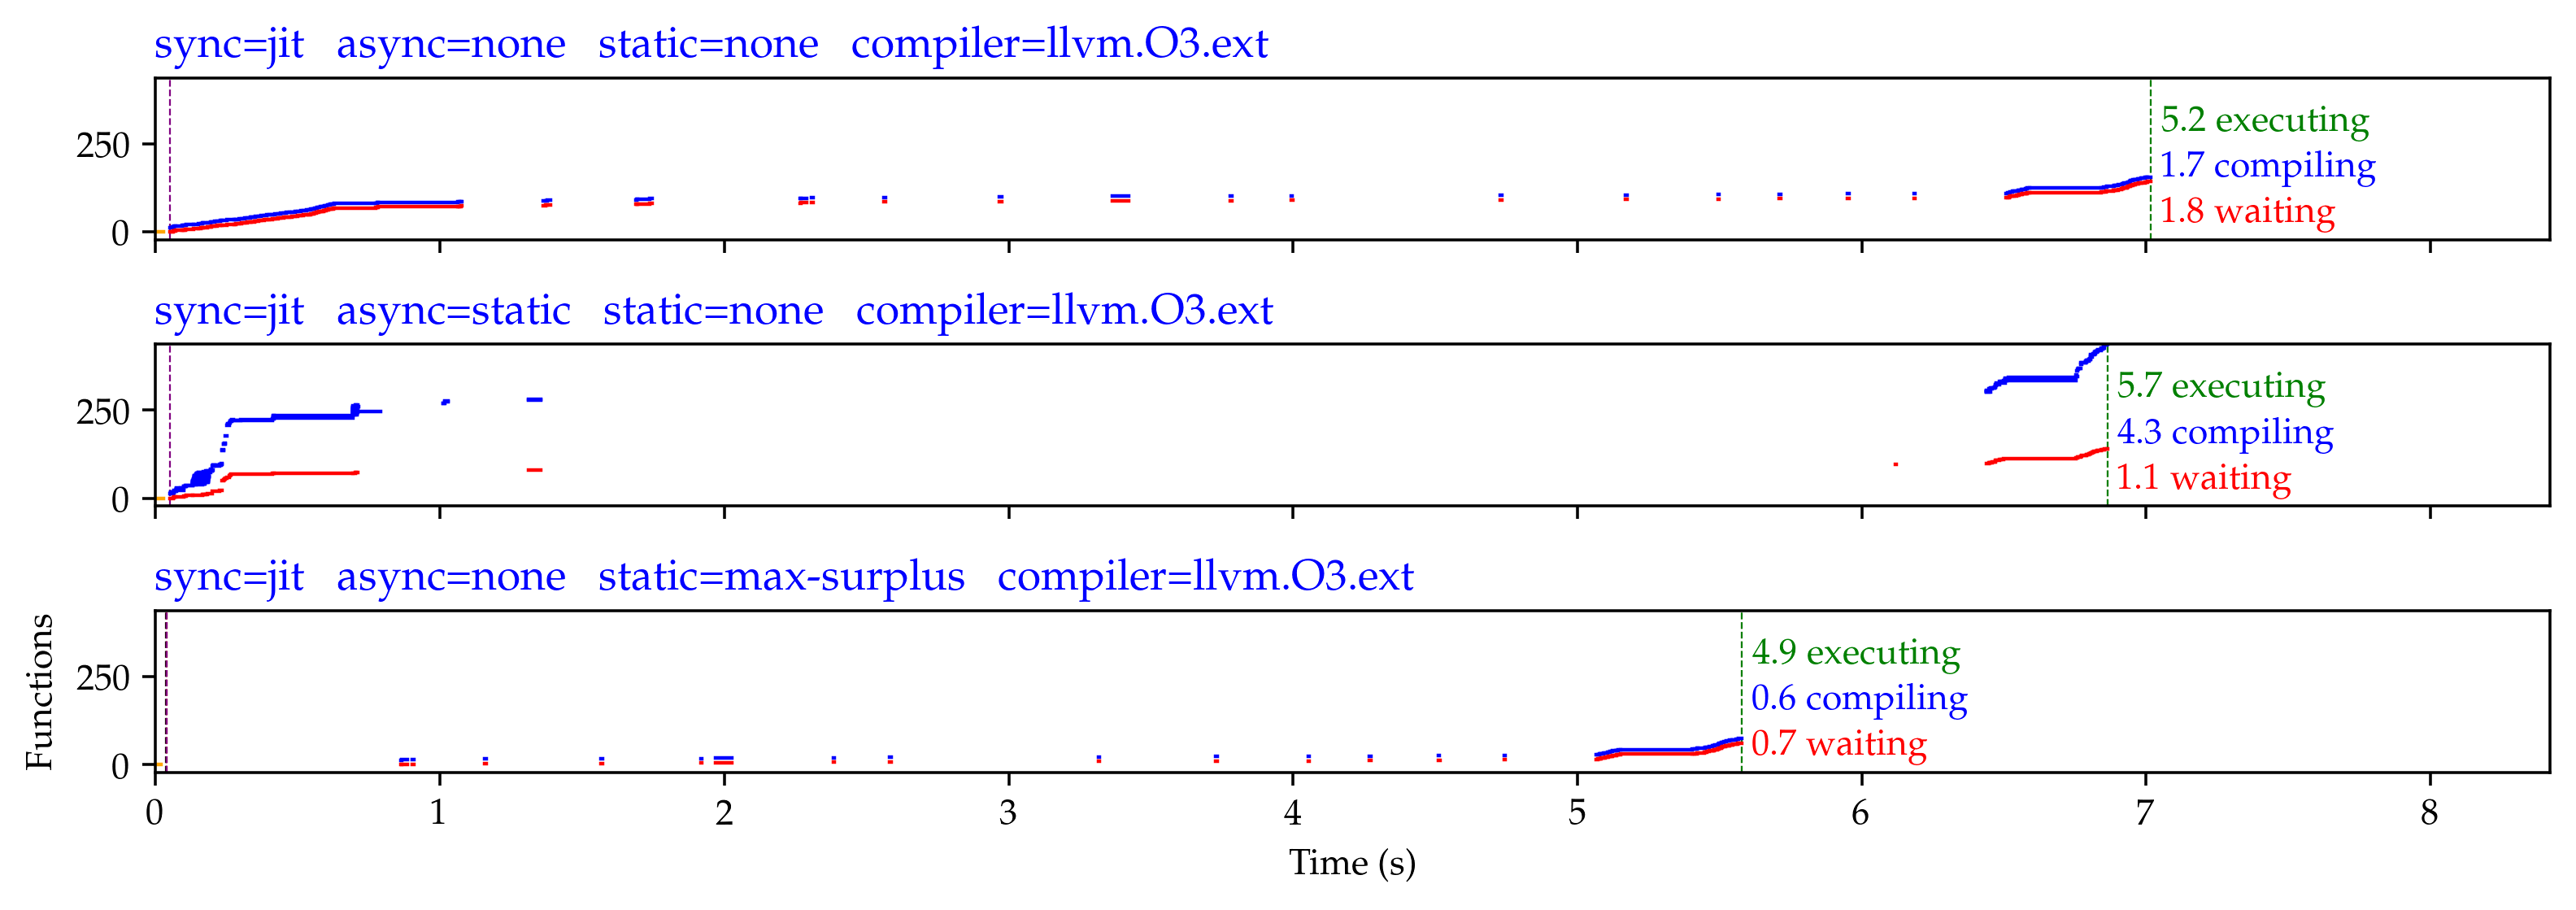

In [14]:
from jetstream.gcc_loops.benchmark import gcc_loops

all_benchmarks = [gcc_loops]

for benchmark in all_benchmarks:
    print(f'benchmark={benchmark.mode}')
    sc.compile(benchmark, ['--compiler=llvm.O3.ext'])
    sap.generate(benchmark)
    schemes = [
        ['--sync=jit'],
        ['--sync=jit', '--async=static'],
        # ['--async=dynamic'],
        ['--static=max-surplus'],
        # ['--async=dynamic', '--static=surplus'],
        # ['--async=dynamic', '--static=surplus', '--specialize'],
        # ['--static=oracle']
    ]
    profiles = []
    for scheme in schemes:
        print(f'scheme={scheme}')
        profile = vm.run(benchmark, scheme)
        if scheme == ['--sync=jit']:
            surplus_point, functions = find_first_surplus_point(profile.virtual_machine.times)
            json.dump(functions, open('/tmp/surplus.json', 'w'))
        profiles.append(profile)
    plot_timelines(benchmark, profiles)
    # break

In [ ]:
profile = profiles[0]
waiting_times = profile.virtual_machine.times  # [f, start, end]
start_time = waiting_times[0][1]
waiting_times = [(f, s - start_time, e - start_time) for f, s, e in waiting_times]
waiting_times
surplus = 0
current_time = 0
for f, s, e in waiting_times:
    surplus += s - current_time
    surplus -= e - s
    current_time = e
    print(f'{f:4} {s:>10} {e:>10} {surplus:>10}')


In [ ]:
import matplotlib.patches as mpatches


def plot_distribution(benchmark, schemes_profiles):
    fig, axs = plt.subplots(figsize=(8, 1 * len(schemes_profiles)), dpi=320, nrows=len(schemes_profiles), ncols=1,
                            sharex=True, sharey=True)
    max_x = 0

    for idx, scheme_profiles in enumerate(schemes_profiles):
        scheme_name = scheme_profiles[0].title
        scheme_latencies = []
        scheme_compilations = []
        scheme_execs = []
        scheme_e2es = []
        for profile in scheme_profiles:
            signature_time = profile.virtual_machine.exec if not profile.signature_service is None else 0
            scheme_latencies.append(profile.virtual_machine.waiting + signature_time)
            scheme_compilations.append(profile.compilation_service.total)
            scheme_execs.append(profile.virtual_machine.exec)
            scheme_e2es.append(profile.end - profile.start)
        max_x = max(max_x, max(scheme_latencies), max(scheme_compilations), max(scheme_execs), max(scheme_e2es))

        ax = axs[idx]
        violins = [
            ax.violinplot(scheme_compilations, showmeans=False, showmedians=False, showextrema=False, vert=False),
            ax.violinplot(scheme_latencies, showmeans=False, showmedians=False, showextrema=False, vert=False),
            ax.violinplot(scheme_execs, showmeans=False, showmedians=False, showextrema=False, vert=False),
            ax.violinplot(scheme_e2es, showmeans=False, showmedians=False, showextrema=False, vert=False),
        ]
        for violin in violins:
            for pc in violin['bodies']:
                pc.set_edgecolor('black')
                pc.set_linewidth(.2)
                pc.set_alpha(.75)

        if idx == 0:
            names = ['Compilation', 'Latency', 'Execution', 'End-to-End']
            colors = []
            for violin in violins:
                color = mpatches.Patch(color=violin["bodies"][0].get_facecolor().flatten())
                color.set_edgecolor('none')
                colors.append(color)
            fig.legend(colors, names,
                       loc='outside upper center',
                       frameon=False,
                       ncol=4)

        ax.yaxis.set_visible(False)

        title = scheme_name
        title = title.replace('no-specialization ', r'')
        title = title.replace('%', r'\%')
        title = title.replace(' ', r'\ \ \ ')
        ax.set_title(title, loc='left', fontweight='bold', color='blue')

    # x is from 0 to max_val
    ax.set_xlim(-.01 * max_x, 1.01 * max_x)

    # print x-axis in seconds
    def format_func(value, _):
        sec = value / 1_000_000_000
        if sec == int(sec):
            return f'{int(sec)}'
        return f'{sec:.1f}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

    ax.set_xlabel('Time (s)')

    plt.tight_layout()

    violin_dir = Path('./out/violin')
    violin_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(violin_dir / f'{benchmark.mode}.pdf', format='pdf', dpi=320, bbox_inches='tight', pad_inches=0.1)

    # plt.close()

    plt.show()

# plot_distribution(benchmark, profiles)

In [ ]:
for benchmark in all_benchmarks:
    print(f'benchmark={benchmark.mode}')
    sc.compile(benchmark)
    sap.generate(benchmark)
    schemes = [
        [],
        ['--async=plan'],
        ['--static=startup.30%'],
        ['--async=plan', '--static=startup.30%'],
        ['--static=startup.100%']
    ]
    profiles = []
    for scheme in schemes:
        print(f'scheme={scheme}')
        scheme_profiles = []
        for i in range(10):
            scheme_profiles.append(vm.run(benchmark, scheme))
        profiles.append(scheme_profiles)
    plot_distribution(benchmark, profiles)